In [6]:
import os

# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)
import scvi

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
import scanpy.external as sce
from sklearn.metrics import silhouette_score
import datetime
import numpy as np
from collections import defaultdict
import scipy.sparse as sp
from collections import defaultdict
import gffutils 

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/GeneExpression


In [7]:
scvi_version = "linear"

### scVI with linear decoder 

/gpfs/commons/home/kisaev/miniconda3/envs/scvi_gpu/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/scvi_gpu/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[length_norm_counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Done reading foundation gene expression file!
Running scVI with linear decoder!


Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/gpfs/commons/home/kisaev/miniconda3/envs/scvi_gpu/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/commons/home/kisaev/miniconda3/envs/scvi_gpu/l ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/gpfs/commons/home/kisaev/miniconda3/envs/scvi_gpu/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightn

Epoch 100/100: 100%|██████████| 100/100 [23:47<00:00,  8.98s/it, v_num=1, train_loss_step=1.49e+3, train_loss_epoch=1.34e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [23:47<00:00, 14.27s/it, v_num=1, train_loss_step=1.49e+3, train_loss_epoch=1.34e+3]
        Z_0       Z_1       Z_2       Z_3       Z_4       Z_5       Z_6  \
0 -0.091259 -0.027393 -0.278066 -0.001539 -0.072569  0.171024 -0.093199   
1 -0.004003 -0.007947 -0.108722 -0.060811 -0.022923  0.029063  0.003629   
2  0.006725  0.051170 -0.051697 -0.061291 -0.052609  0.149946 -0.066330   
3 -0.016272  0.039195 -0.115502 -0.024818 -0.126678  0.027469  0.006032   
4 -0.049762 -0.079946 -0.003535  0.045125  0.038434  0.036271 -0.114392   

        Z_7       Z_8       Z_9  ...      Z_40      Z_41      Z_42      Z_43  \
0 -0.029734  0.254719  0.029141  ... -0.054166  0.189704 -0.021061 -0.179948   
1  0.068752 -0.141262  0.003150  ... -0.007397  0.013130  0.014450 -0.052364   
2 -0.023354 -0.127034  0.020919  ... -0.036711 -0.036263 -0.075248  0.040497   
3  0.086368 -0.161755 -0.029429  ... -0.062291  0.014229  0.015919 -0.147983   
4  0.080349 -0.151933 -0

/scratch/ipykernel_2886242/3419264265.py:37: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ge_adata, key_added="leiden_scVI", resolution=0.8)


Saved updated AnnData with LinearSCVI results to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_linearSCVI_2025-04-29.h5ad


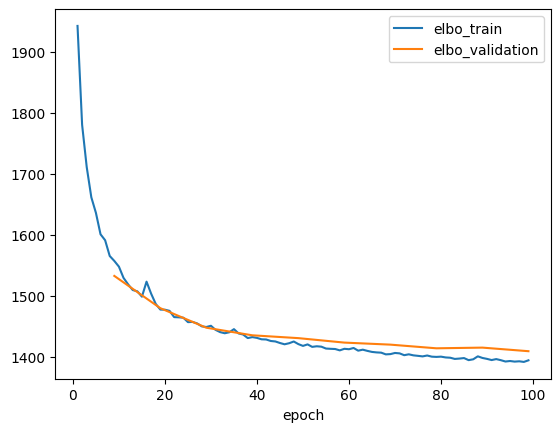

In [8]:
# Set up paths for files 
gene_exp_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/042025/mouse_foundation_data_20250428_151440_ge.h5ad"  
ge_adata = ad.read_h5ad(gene_exp_file)
print(f"Done reading foundation gene expression file!")

if scvi_version == "linear":

    print(f"Running scVI with linear decoder!")
    # Model input setup
    scvi.model.LinearSCVI.setup_anndata(ge_adata, layer="length_norm_counts", batch_key="dataset")

    # Initialize LinearSCVI model
    model = scvi.model.LinearSCVI(ge_adata, n_latent=50)

    # Train for 250 epochs, compute metrics every 10 epochs
    model.train(max_epochs=100, check_val_every_n_epoch=10)

    train_elbo = model.history["elbo_train"][1:]
    test_elbo = model.history["elbo_validation"]

    ax = train_elbo.plot()
    test_elbo.plot(ax=ax)

    Z_hat = model.get_latent_representation()
    for i, z in enumerate(Z_hat.T):
        ge_adata.obs[f"Z_{i}"] = z

    loadings = model.get_loadings()
    print(loadings.head())

    # These top genes can be interpreted as following most of the structural variation in the data.
    # The LinearSCVI model further supports the same scVI functionality as the SCVI model, 
    # so all posterior methods work the same.
    ge_adata.obsm["X_scVI"] = Z_hat
    sc.pp.neighbors(ge_adata, use_rep="X_scVI", n_neighbors=20)
    sc.tl.umap(ge_adata, min_dist=0.3)
    sc.tl.leiden(ge_adata, key_added="leiden_scVI", resolution=0.8)

    # Save updated gene expression anndata object 
    # Define save path
    today = datetime.datetime.now().strftime("%Y-%m-%d")
    output_file = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_linearSCVI_{today}.h5ad"

    ge_adata.write_h5ad(output_file, compression="lzf")
    print(f"Saved updated AnnData with LinearSCVI results to {output_file}")

else:
    print(f"Runnign regular scVI!")
    # Set up scVI input
    scvi.model.SCVI.setup_anndata(ge_adata, layer="length_norm", batch_key="dataset")

    # Initialize SCVI model (nonlinear decoder)
    model = scvi.model.SCVI(ge_adata, n_latent=30)

    # Train model
    model.train(max_epochs=300, check_val_every_n_epoch=10)

    # Extract ELBO loss curves
    train_elbo = model.history["elbo_train"][1:]
    test_elbo = model.history["elbo_validation"]

    # Plot training and validation ELBO
    ax = train_elbo.plot()
    test_elbo.plot(ax=ax)

    # Get latent space
    Z_hat = model.get_latent_representation()

    # Save latent dimensions into .obs
    for i, z in enumerate(Z_hat.T):
        ge_adata.obs[f"Z_{i}"] = z

    # Save latent space embedding
    ge_adata.obsm["X_scVI_full"] = Z_hat

    # Run neighbors, UMAP, Leiden clustering
    sc.pp.neighbors(ge_adata, use_rep="X_scVI_full", n_neighbors=20)
    sc.tl.umap(ge_adata, min_dist=0.3)
    sc.tl.leiden(ge_adata, key_added="leiden_scVI_full", resolution=0.8)

    # Save updated AnnData
    today = datetime.datetime.now().strftime("%Y-%m-%d")
    output_file = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_scVI_{today}.h5ad"

    ge_adata.write_h5ad(output_file, compression="lzf")
    print(f"Saved updated AnnData with SCVI results to {output_file}")
